### Logistic Regression

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 



In [3]:
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
df = pd.read_csv('Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
data = df[df.duplicated()]
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio


In [6]:
df['age'] = df['age'] // 365

<Axes: >

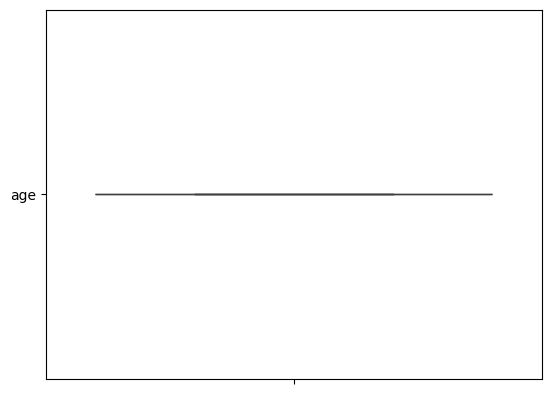

In [7]:
sns.boxplot('age')

<Axes: ylabel='Count'>

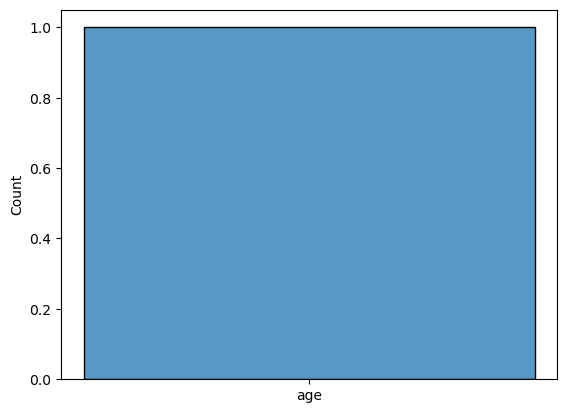

In [8]:
sns.histplot('age')

In [9]:
df['age'].unique()

array([50, 55, 51, 48, 47, 60, 61, 54, 40, 39, 45, 58, 59, 63, 64, 53, 49,
       57, 56, 46, 43, 62, 52, 42, 44, 41, 29, 30], dtype=int64)

In [10]:
df['gender'].unique()

array([2, 1], dtype=int64)

In [11]:
data = df[(df['height'].between(150,200)) & (df['weight'].between (45,120)) &(df['ap_hi'].between (100,200)) &(df['ap_lo'].between (60,90))]

In [12]:
data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


In [13]:
data = data.drop( columns = 'id')

In [14]:
data.corr()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.027036,-0.081389,0.060352,0.206005,0.149713,0.149897,0.095319,-0.049190,-0.031198,-0.011789,0.242835
gender,-0.027036,1.000000,0.514690,0.150061,0.046475,0.052009,-0.040778,-0.025335,0.336915,0.166305,0.006907,-0.003274
height,-0.081389,0.514690,1.000000,0.298447,0.008468,0.030811,-0.057945,-0.025533,0.191612,0.093397,-0.008458,-0.019399
weight,0.060352,0.150061,0.298447,1.000000,0.228258,0.201255,0.134725,0.093669,0.065612,0.061209,-0.015394,0.162397
ap_hi,0.206005,0.046475,0.008468,0.228258,1.000000,0.616712,0.181938,0.083847,0.023808,0.021503,-0.001303,0.412751
ap_lo,0.149713,0.052009,0.030811,0.201255,0.616712,1.000000,0.135179,0.058835,0.017366,0.021939,-0.000844,0.293957
cholesterol,0.149897,-0.040778,-0.057945,0.134725,0.181938,0.135179,1.000000,0.452874,0.008363,0.026451,0.006808,0.221429
gluc,0.095319,-0.025335,-0.025533,0.093669,0.083847,0.058835,0.452874,1.000000,-0.006751,0.004251,-0.008513,0.086893
smoke,-0.049190,0.336915,0.191612,0.065612,0.023808,0.017366,0.008363,-0.006751,1.000000,0.345966,0.027773,-0.022741
alco,-0.031198,0.166305,0.093397,0.061209,0.021503,0.021939,0.026451,0.004251,0.345966,1.000000,0.025641,-0.019316


<Axes: >

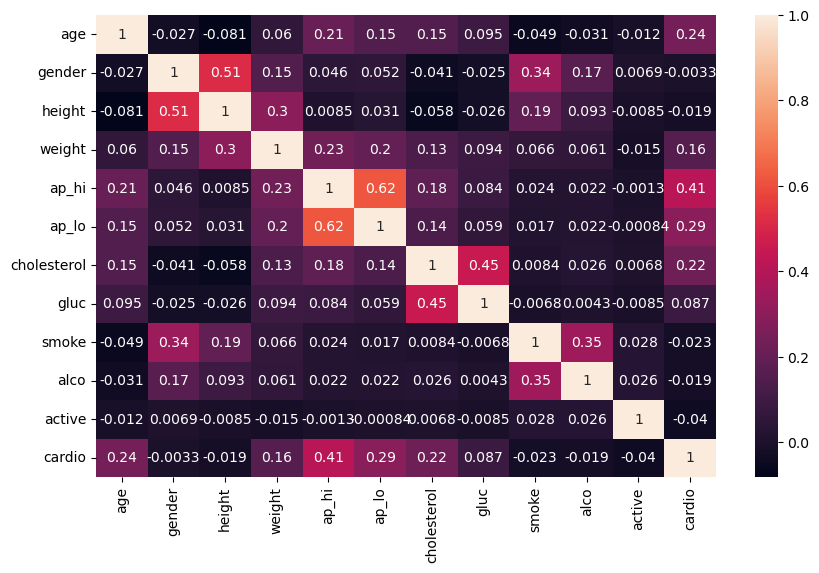

In [15]:
cor = data.corr()
plt.figure(figsize = (10,6))
sns.heatmap(cor, annot = True)

In [16]:
data.columns


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [17]:
feature = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'] 
target = 'cardio'

In [18]:
X= data[feature]
Y= data[target]

In [19]:
X_train, X_test,Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state= 42, stratify = Y
    

)

In [20]:
scaler = StandardScaler()

In [21]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [22]:

X_train_scale

array([[ 0.48031824,  1.34932235,  0.28520419, ..., -0.31221857,
        -0.23677706,  0.49662306],
       [-0.1103595 , -0.74111275, -1.21013714, ..., -0.31221857,
        -0.23677706,  0.49662306],
       [ 1.51400427, -0.74111275,  0.69302455, ..., -0.31221857,
        -0.23677706,  0.49662306],
       ...,
       [ 1.07099597, -0.74111275,  0.9649048 , ..., -0.31221857,
        -0.23677706,  0.49662306],
       [-0.40569837, -0.74111275,  0.01332395, ..., -0.31221857,
        -0.23677706,  0.49662306],
       [-0.1103595 ,  1.34932235,  2.32430601, ...,  3.20288443,
        -0.23677706,  0.49662306]])

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

In [30]:
model.fit(X_train_scale, Y_train)

LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')

In [32]:
Y_pred = model.predict(X_train_scale)